# Chapter 02 Hypothesis Testing: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-02-hypothesis-testing-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

Recall the checkout API from Chapter 1: an on-call engineer watching a right-skewed latency
distribution, worried that the mean hides a growing slow tail. Suppose that engineer's team
ships a caching layer meant to cut that latency, and the dashboard shows a lower number the
next morning.

Is the cache working, or did traffic happen to be lighter overnight? *Hypothesis testing* is
the machinery for answering that question with a number instead of a guess.

This chapter works through six questions that come up each time an engineer or data
scientist has to decide whether an observed difference means something:

1. *How do I state a claim so a sample of data can test it?*
   Hypothesis statements turn "the cache helped" into something a formula can evaluate.
2. *How do I test a claim about a single average?*
   The Z-test and t-test compare a sample mean against a target value.
3. *What does a p-value tell me, and where does that stop?*
   A p-value is one of the most quoted and most misread numbers in applied statistics.
4. *What are the two ways a test can be wrong, and what does each one cost?*
   Type I and Type II errors trade off against each other, and the trade is a business
   decision, not just a statistical one.
5. *How much data does a decision need before it can be trusted?*
   Statistical power and sample size determine how long a test needs to run.
6. *What happens when there are more than two groups, more than one confounder, or data that
   refuses to look normal?*
   ANOVA, chi-squared tests, ANCOVA, experimental design, and non-parametric alternatives
   cover the cases a simple t-test cannot.7. *How do I turn a single estimate into a range I can trust, or compare two proportions
   instead of two means?*
   Confidence intervals and the two-proportion z-test extend the machinery above to estimates
   and proportions directly.
8. *What goes wrong when a test gets checked before it is finished, or when many tests run at
   once?*
   Sequential testing and the multiple-comparisons problem cover two of the most common ways a
   correct test still misleads a team in production.


In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from scipy import stats

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(7)

`power_two_sample` is a helper used by the figures below.

In [4]:
def power_two_sample(n: np.ndarray, effect_size: float, alpha: float = 0.05) -> np.ndarray:
    """Normal-approximation power for a two-sample test, illustrative (not a substitute
    for a dedicated power-analysis library on a production sample-size decision)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    ncp = effect_size * np.sqrt(n / 2)
    return (1 - stats.norm.cdf(z_alpha - ncp)) + stats.norm.cdf(-z_alpha - ncp)

## Testing a single mean: the Z-test and the t-test

The t-distribution's tails thin toward the standard normal as degrees of freedom increase. Below roughly 10 degrees of freedom the extra tail weight is easy to see; above 30 the two curves are nearly impossible to tell apart.

In [5]:
def fig_t_vs_normal() -> go.Figure:
    x = np.linspace(-5, 5, 400)
    normal_pdf = stats.norm.pdf(x)
    dfs = [1, 2, 5, 10, 30, 100]
    frames = []
    for df in dfs:
        t_pdf = stats.t.pdf(x, df)
        frames.append(
            go.Frame(
                name=str(df),
                data=[
                    go.Scatter(x=x, y=normal_pdf, mode="lines", name="Standard normal",
                               line=dict(color="#4C78A8", width=2, dash="dash")),
                    go.Scatter(x=x, y=t_pdf, mode="lines", name="t-distribution",
                               line=dict(color="#E45756", width=2.5)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="The t-distribution's tails thin toward the normal as df increases",
        xaxis_title="value",
        yaxis_title="density",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "degrees of freedom: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

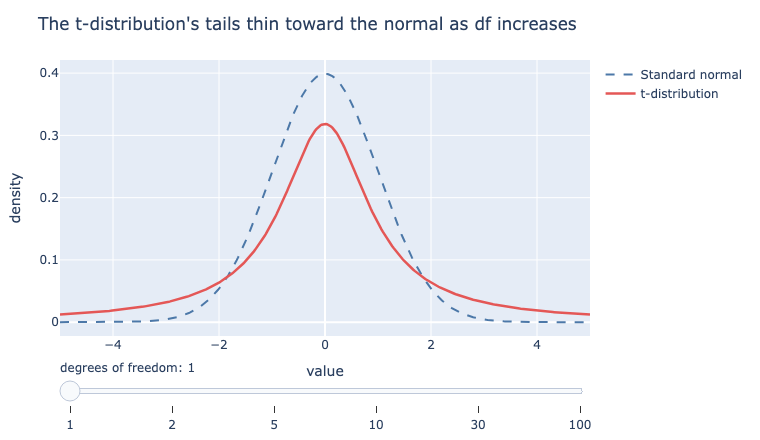

In [6]:
show(fig_t_vs_normal())

## Type I and Type II errors: the two ways to be wrong

Moving the significance threshold trades Type I error against Type II error. Pulling the threshold in one direction to catch more true effects always lets in more false positives at the same time.

In [7]:
def fig_type1_type2() -> go.Figure:
    x = np.linspace(-4, 8, 600)
    null_pdf = stats.norm.pdf(x, loc=0, scale=1)
    alt_pdf = stats.norm.pdf(x, loc=3, scale=1)
    thresholds = [1.0, 1.5, 1.96, 2.5, 3.0]
    frames = []
    for thr in thresholds:
        type1 = 1 - stats.norm.cdf(thr, loc=0, scale=1)
        type2 = stats.norm.cdf(thr, loc=3, scale=1)
        mask1 = x >= thr
        mask2 = x <= thr
        frames.append(
            go.Frame(
                name=f"{thr:.2f}",
                data=[
                    go.Scatter(x=x, y=null_pdf, mode="lines", name="Null (no effect)",
                               line=dict(color="#4C78A8", width=2)),
                    go.Scatter(x=x, y=alt_pdf, mode="lines", name="Alternative (true effect)",
                               line=dict(color="#54A24B", width=2)),
                    go.Scatter(x=x[mask1], y=null_pdf[mask1], fill="tozeroy",
                               mode="none", name="Type I error region",
                               fillcolor="rgba(228,87,86,0.45)"),
                    go.Scatter(x=x[mask2], y=alt_pdf[mask2], fill="tozeroy",
                               mode="none", name="Type II error region",
                               fillcolor="rgba(245,133,24,0.45)"),
                ],
                layout=go.Layout(
                    shapes=[dict(type="line", x0=thr, x1=thr, y0=0, y1=1, yref="paper",
                                 line=dict(color="#333", width=1.5, dash="dot"))],
                    annotations=[dict(
                        x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                        xanchor="right",
                        text=f"Type I (alpha) = {type1:.3f}<br>Type II (beta) = {type2:.3f}",
                        font=dict(size=13, color="#333"),
                    )],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Moving the significance threshold trades Type I error against Type II error",
        xaxis_title="test statistic",
        yaxis_title="density",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "decision threshold: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

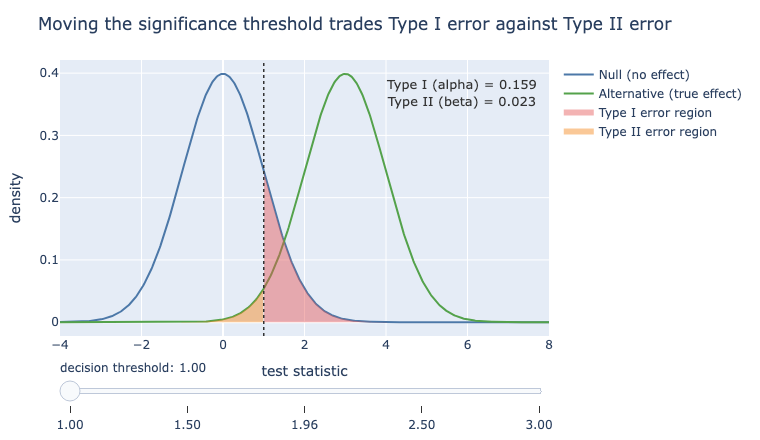

In [8]:
show(fig_type1_type2())

## Statistical power: how long to run the canary

Statistical power rises with sample size, more slowly for smaller effect sizes. A small true effect can need many times more traffic than a large one before a test reliably notices it.

In [9]:
def fig_power_curve() -> go.Figure:
    n = np.linspace(5, 500, 200)
    effect_sizes = [0.1, 0.2, 0.3, 0.5, 0.8]
    frames = []
    for d in effect_sizes:
        power = power_two_sample(n, d)
        frames.append(
            go.Frame(
                name=f"{d:.1f}",
                data=[go.Scatter(x=n, y=power, mode="lines", line=dict(color="#4C78A8", width=3))],
                layout=go.Layout(shapes=[dict(
                    type="line", x0=0, x1=1, xref="paper", y0=0.8, y1=0.8,
                    line=dict(color="#E45756", width=1.5, dash="dash"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Statistical power rises with sample size, more slowly for smaller effects",
        xaxis_title="sample size per group (n)",
        yaxis_title="power",
        yaxis_range=[0, 1],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "effect size (Cohen's d): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

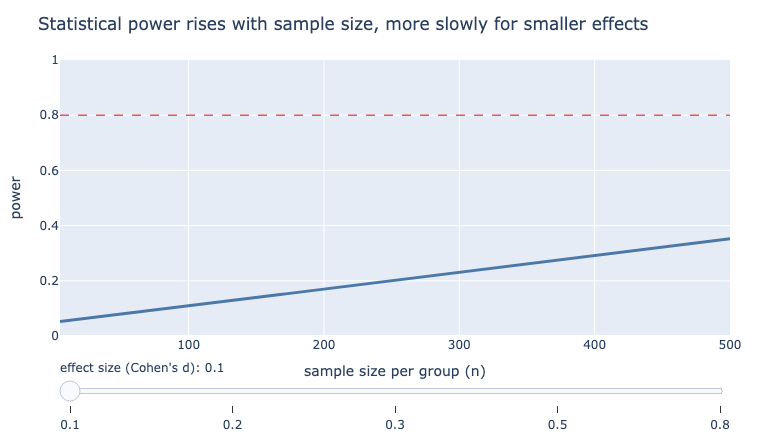

In [10]:
show(fig_power_curve())

## When the data will not cooperate: non-parametric tests

A t-test's p-value moves more than a Wilcoxon rank-sum test's as outliers are added to skewed data. The rank-based test barely reacts, since a single extreme value can only move a rank by one position.

In [11]:
def fig_parametric_vs_nonparametric() -> go.Figure:
    n = 200
    base_control = RNG.lognormal(mean=np.log(45), sigma=0.35, size=n)
    base_treatment = RNG.lognormal(mean=np.log(40), sigma=0.35, size=n)
    contaminations = [0, 1, 2, 3, 5]
    frames = []
    for k in contaminations:
        control = base_control.copy()
        treatment = base_treatment.copy()
        if k:
            idx = RNG.choice(n, size=k, replace=False)
            control[idx] = RNG.lognormal(mean=np.log(600), sigma=0.3, size=k)
        t_stat, t_p = stats.ttest_ind(control, treatment, equal_var=False)
        w_stat, w_p = stats.mannwhitneyu(control, treatment, alternative="two-sided")
        hist_c = np.histogram(control, bins=np.linspace(0, 800, 60))
        hist_t = np.histogram(treatment, bins=np.linspace(0, 800, 60))
        frames.append(
            go.Frame(
                name=str(k),
                data=[
                    go.Bar(x=hist_c[1][:-1], y=hist_c[0], name="Control", opacity=0.6,
                           marker_color="#4C78A8"),
                    go.Bar(x=hist_t[1][:-1], y=hist_t[0], name="Treatment", opacity=0.6,
                           marker_color="#54A24B"),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"t-test p = {t_p:.4f}<br>Wilcoxon rank-sum p = {w_p:.4f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        barmode="overlay",
        title="A t-test's p-value moves more than a Wilcoxon rank-sum test's as outliers "
              "are added",
        xaxis_title="latency (ms)",
        yaxis_title="count",
        xaxis_range=[0, 800],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "outlier requests added to control: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

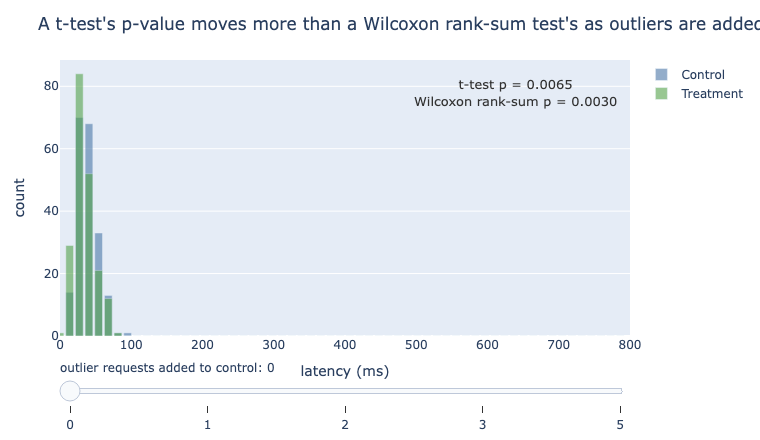

In [12]:
show(fig_parametric_vs_nonparametric())

## Comparing three or more groups: ANOVA

Three regions' latency distributions as the gap between their means widens. F rises and p falls even though the spread within each region never changes.

In [13]:
def fig_anova_between_within() -> go.Figure:
    n_per_group = 60
    within_sigma = 12.0
    base_means = [45.0, 45.0, 45.0]
    gaps = [0.0, 3.0, 8.0, 15.0, 25.0]
    frames = []
    for gap in gaps:
        means = [base_means[0] - gap / 2, base_means[1], base_means[2] + gap / 2]
        groups = [RNG.normal(loc=m, scale=within_sigma, size=n_per_group) for m in means]
        f_stat, p_val = stats.f_oneway(*groups)
        frames.append(
            go.Frame(
                name=f"{gap:.0f}",
                data=[
                    go.Box(y=groups[0], name="Region A", marker_color="#4C78A8",
                           boxpoints="all", jitter=0.4, pointpos=0),
                    go.Box(y=groups[1], name="Region B", marker_color="#54A24B",
                           boxpoints="all", jitter=0.4, pointpos=0),
                    go.Box(y=groups[2], name="Region C", marker_color="#F58518",
                           boxpoints="all", jitter=0.4, pointpos=0),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.97, xref="paper", yref="paper", showarrow=False,
                    xanchor="left",
                    text=f"F = {f_stat:.2f}<br>p = {p_val:.4f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="ANOVA: as the gap between region means grows, F rises and p falls",
        yaxis_title="Latency (ms)",
        showlegend=False,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Gap between region means (ms): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

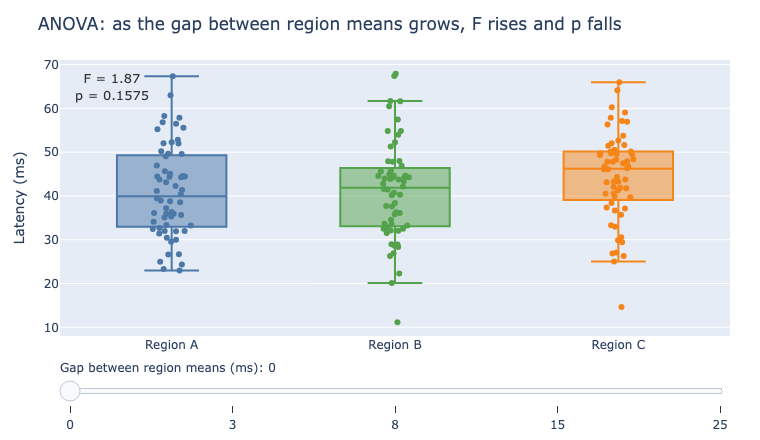

In [14]:
show(fig_anova_between_within())

## Paired and unpaired t-tests

Shuffling which latency values belong to "control" and which belong to "cached" 20,000 times, and recomputing the difference in group means after each shuffle, builds a null distribution with no formula involved. The observed difference sits far out in that distribution's tail.

In [15]:
def fig_permutation_null() -> go.Figure:
    rng_data = np.random.default_rng(2019)
    n1, n2 = 60, 60
    control = rng_data.lognormal(mean=np.log(50), sigma=0.38, size=n1)
    treatment = rng_data.lognormal(mean=np.log(41), sigma=0.38, size=n2)
    obs_diff = control.mean() - treatment.mean()
    _, welch_p = stats.ttest_ind(control, treatment, equal_var=False)

    pooled = np.concatenate([control, treatment])
    rng_perm = np.random.default_rng(2024)
    max_shuffles = 20000
    diffs = np.empty(max_shuffles)
    for i in range(max_shuffles):
        shuffled = rng_perm.permutation(pooled)
        diffs[i] = shuffled[:n1].mean() - shuffled[n1:].mean()

    shuffle_counts = [100, 500, 1000, 5000, 20000]
    frames = []
    for m in shuffle_counts:
        subset = diffs[:m]
        perm_p = np.mean(np.abs(subset) >= np.abs(obs_diff))
        hist = np.histogram(subset, bins=40)
        frames.append(
            go.Frame(
                name=str(m),
                data=[
                    go.Bar(x=hist[1][:-1], y=hist[0], marker_color="#4C78A8",
                           name="Permuted mean differences"),
                ],
                layout=go.Layout(
                    shapes=[dict(type="line", x0=obs_diff, x1=obs_diff, y0=0, y1=1,
                                 yref="paper", line=dict(color="#E45756", width=2, dash="dash"))],
                    annotations=[dict(
                        x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                        xanchor="right",
                        text=(f"observed diff = {obs_diff:.1f} ms<br>"
                              f"permutation p = {perm_p:.4f}<br>"
                              f"Welch t-test p = {welch_p:.4f}"),
                        font=dict(size=13, color="#333"),
                    )],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Shuffling the group labels builds a null distribution before any formula",
        xaxis_title="permuted difference in mean latency (ms)",
        yaxis_title="count",
        showlegend=False,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "shuffles so far: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

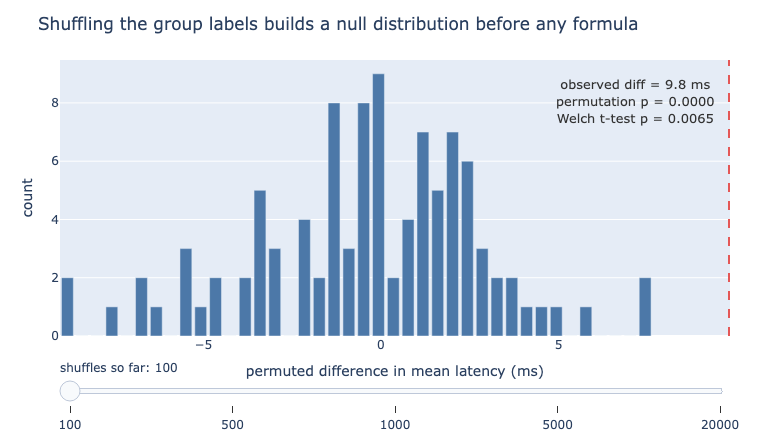

In [16]:
show(fig_permutation_null())

## Confidence intervals for a mean and a proportion

Resampling the same 25-request sample thousands of times and recomputing its mean each time traces out how much that mean would wobble on a re-draw. Demanding more confidence widens the interval; there is no way to buy both narrowness and certainty at once.

In [17]:
def fig_ci_bootstrap() -> go.Figure:
    rng_ci = np.random.default_rng(31)
    n_small = 25
    small_sample = rng_ci.lognormal(mean=np.log(43), sigma=0.35, size=n_small)

    n_boot = 10000
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        resample = rng_ci.choice(small_sample, size=n_small, replace=True)
        boot_means[i] = resample.mean()

    hist = np.histogram(boot_means, bins=50)
    confidence_levels = [80, 90, 95, 99]
    frames = []
    for conf in confidence_levels:
        lo_pct = (100 - conf) / 2
        hi_pct = 100 - lo_pct
        lo, hi = np.percentile(boot_means, [lo_pct, hi_pct])
        frames.append(
            go.Frame(
                name=f"{conf}",
                data=[go.Bar(x=hist[1][:-1], y=hist[0], marker_color="#4C78A8",
                              name="Bootstrap resample means")],
                layout=go.Layout(
                    shapes=[
                        dict(type="line", x0=lo, x1=lo, y0=0, y1=1, yref="paper",
                             line=dict(color="#E45756", width=2, dash="dash")),
                        dict(type="line", x0=hi, x1=hi, y0=0, y1=1, yref="paper",
                             line=dict(color="#E45756", width=2, dash="dash")),
                    ],
                    annotations=[dict(
                        x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                        xanchor="right",
                        text=f"{conf}% CI: [{lo:.1f}, {hi:.1f}] ms<br>width = {hi - lo:.1f} ms",
                        font=dict(size=13, color="#333"),
                    )],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A wider confidence interval buys more certainty, at the cost of precision",
        xaxis_title="bootstrap resample mean latency (ms)",
        yaxis_title="count",
        showlegend=False,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "confidence level: "},
            "steps": [
                {"label": f.name + "%", "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

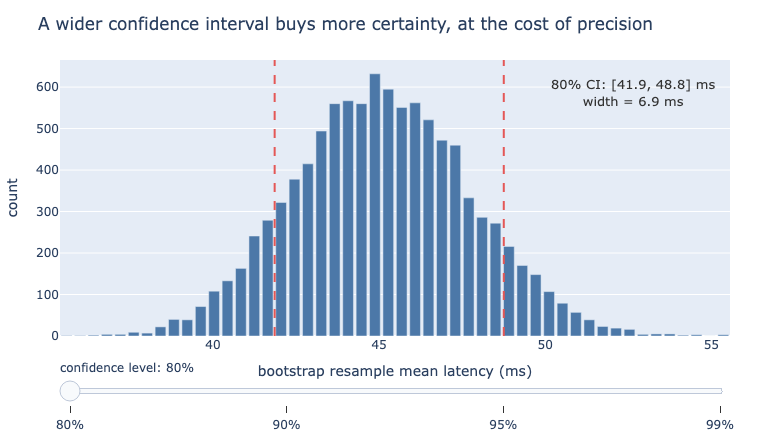

In [18]:
show(fig_ci_bootstrap())

## Sequential testing: the cost of checking early

Two thousand simulated A/B tests, each built with no difference between control and treatment, checked every 100 requests per group instead of once at the end. The share flagged significant climbs well past the nominal 5 percent as the checking continues.

In [19]:
def fig_peeking() -> go.Figure:
    rng_peek = np.random.default_rng(2026)
    n_experiments = 2000
    max_n_per_group = 2000
    check_every = 100
    checkpoints = np.arange(check_every, max_n_per_group + 1, check_every)

    first_cross_day = np.full(n_experiments, np.nan)
    for e in range(n_experiments):
        a_full = rng_peek.normal(loc=45, scale=15, size=max_n_per_group)
        b_full = rng_peek.normal(loc=45, scale=15, size=max_n_per_group)
        for cp in checkpoints:
            _, p = stats.ttest_ind(a_full[:cp], b_full[:cp], equal_var=False)
            if p < 0.05:
                first_cross_day[e] = cp
                break

    experiment_counts = [200, 500, 1000, 2000]
    frames = []
    for m in experiment_counts:
        subset = first_cross_day[:m]
        cumulative_rate = [np.mean(subset <= cp) for cp in checkpoints]
        frames.append(
            go.Frame(
                name=str(m),
                data=[
                    go.Scatter(x=checkpoints, y=cumulative_rate, mode="lines+markers",
                               name="Checked every 100 requests (peeking)",
                               line=dict(color="#E45756", width=3)),
                    go.Scatter(x=checkpoints, y=[0.05] * len(checkpoints), mode="lines",
                               name="Single planned look (nominal alpha)",
                               line=dict(color="#4C78A8", width=2, dash="dash")),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="left",
                    text=f"based on {m} simulated null-true experiments<br>"
                         f"cumulative false-positive rate so far = {cumulative_rate[-1]:.3f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Checking a dashboard after every batch inflates the false-positive rate",
        xaxis_title="requests per group collected so far",
        yaxis_title="share of null-true experiments flagged significant so far",
        yaxis_range=[0, 0.3],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "simulated experiments: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300, "redraw": True}, "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

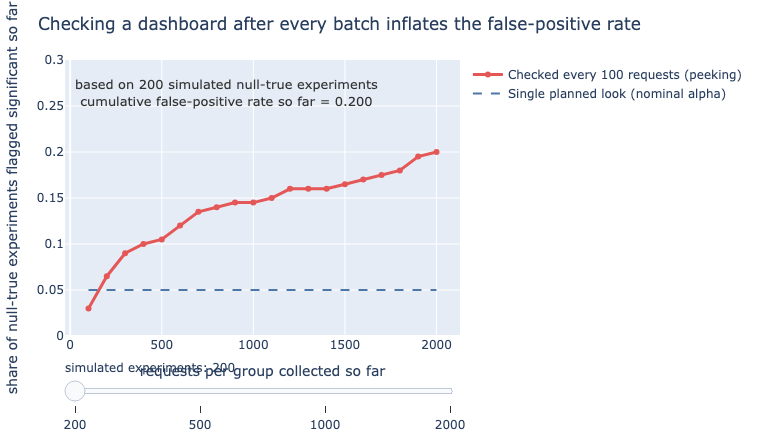

In [20]:
show(fig_peeking())